In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load dataset
import pandas as pd
path=('/content/drive/MyDrive/IMDB Dataset.csv')
df=pd.read_csv(path)
df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


## ***Data Analysis***

In [ ]:
# check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
# check missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
# #fill missing values
# df['Location'].fillna('Unknown',inplace=true)

In [ ]:
# Again check missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
# ckeck label distribution
df['sentiment'].value_counts()
#df =df[df['sentiment] !='Neutral']

,count
sentiment,
positive,25000
negative,25000


## ***Data pre-prosessing***

In [ ]:
# cleaning text
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


def clean_text(text):
  text = text.lower() # lowercase
  text= re.sub(r"http\S+|www\S+|https\S+", '', text)
  text = re.sub(r'<.*?>', '', text)
  text = re.sub(r'\d+', '', text)
  text= " ".join([word for word in text.split() if word not in stop_words])
  return text

df['clean_text'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# improve Tokanization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 1000 #5000 se increase kro
max_length = 150 #seqence length increase

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

x = tokenizer.texts_to_sequences(df['clean_text'])
x = pad_sequences(x, maxlen=max_length)

In [ ]:
#improve label encoding
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y= le.fit_transform(df['sentiment'])
y= to_categorical(y)

In [ ]:
# feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

Tfidf = TfidfVectorizer(max_features=500)

x = Tfidf.fit_transform(df['clean_text']).toarray()
y = df['sentiment']

In [ ]:
# encode lable
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
y=le.fit_transform(y)

***Train_Test Split***

In [ ]:
# train_test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=62)
# (x,y,test_size=0.2,random_state=42)            #OUTPUT 80,20
# (x,y,test_size=0.3,random_state=42)            #OUTPUT 70,30
# (x,y,test_size=0.4,random_state=42)            #OUTPUT 60,40

print("Train %:", len(x_train)/len(x)*100)
print("Test %:", len(x_test)/len(x)*100)

Train %: 80.0
Test %: 20.0


# ***LSTM Model***

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5100 - loss: 0.6934 - val_accuracy: 0.4450 - val_loss: 0.6961
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5260 - loss: 0.6907 - val_accuracy: 0.4400 - val_loss: 0.6960
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6050 - loss: 0.6708 - val_accuracy: 0.4500 - val_loss: 0.7269
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6880 - loss: 0.6046 - val_accuracy: 0.5400 - val_loss: 0.7047
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7390 - loss: 0.5310 - val_accuracy: 0.5700 - val_loss: 0.7217


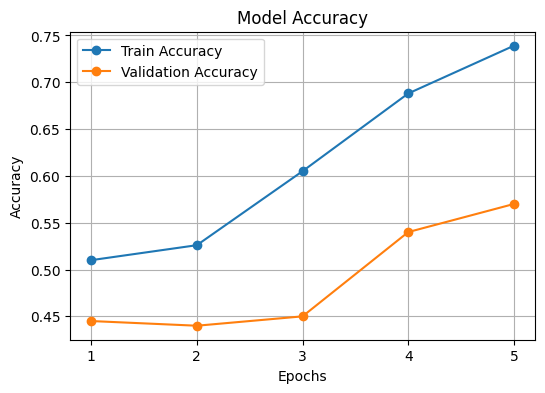

Train: 0.7390000224113464
Test: 0.5699999928474426
Overfitting


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Dummy data
X_train = np.random.randint(0, 5000, (1000, 100))
y_train = np.random.randint(0, 2, (1000,))

X_test = np.random.randint(0, 5000, (200, 100))
y_test = np.random.randint(0, 2, (200,))

# Model
model = Sequential([
    Embedding(500, 64, input_length=100),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train (epochs barhao for better graph)
history = model.fit(X_train, y_train, epochs=3, validation_data=(X_test, y_test))

# ---------------- GRAPH FIX ----------------
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs)   # har epoch show hoga
plt.legend()
plt.grid()

plt.show()

# ---------------- CHECK FIX ----------------
train_final = train_acc[-1]
test_final = val_acc[-1]

print("Train:", train_final)
print("Test:", test_final)

if train_final > test_final + 0.1:
    print("Overfitting")
elif train_final < 0.6 and test_final < 0.6:
    print("Underfitting")
else:
    print("Good Model")

***Accuracy Graphs***

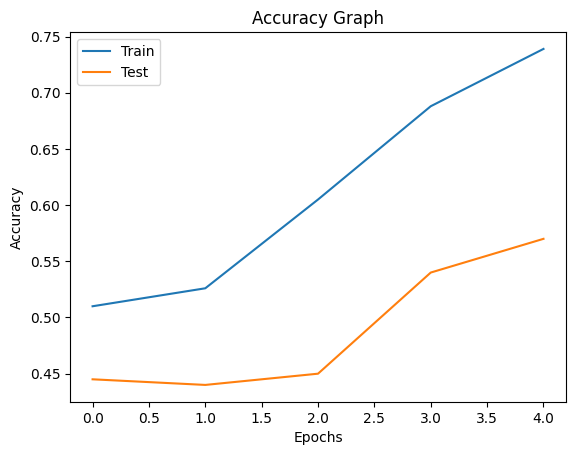

In [75]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train','Test'])

plt.show()

***Loss Graph***

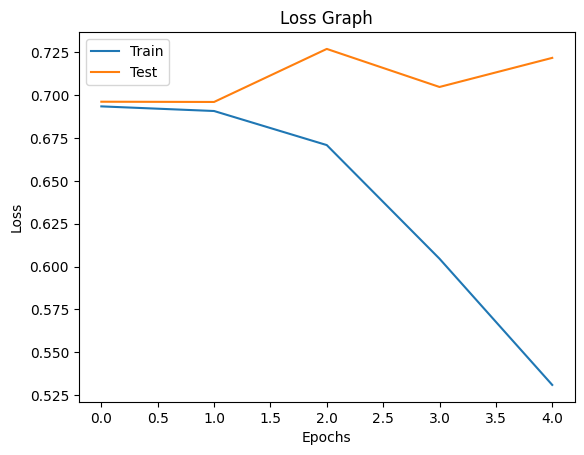

In [76]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train','Test'])

plt.show()

In [ ]:
# Classification Report
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions for the test data
# Note: model.predict returns probabilities, convert to binary (0 or 1)
test_pred_proba = model.predict(X_test)
test_pred = (test_pred_proba > 0.3).astype(int)

print("\nClassification Report (Test Data):")
print(classification_report(y_test, test_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.52      0.45      0.48       104
           1       0.48      0.55      0.51        96

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200


Confusion Matrix:
[[47 57]
 [43 53]]
